In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_context('paper', font_scale=2., rc={"lines.linewidth": 1.75} )
sns.set_style({'font.weight': 'bold'})

# Markers
plt.rcParams['lines.markersize'] = 6.5
plt.rcParams['lines.linewidth'] = 1.75
plt.rcParams['figure.figsize'] = (8.7,6.27)

In [14]:
copy_dataframe = pd.read_csv(f"../bench_results_copy_fp16.csv")
# Input -> FP16 
# Output -> FP16
copy_dataframe['mem_bytes'] = (copy_dataframe['size'] * 2)  + copy_dataframe['size'] * 2
copy_dataframe['bandwidth_gbps'] = (copy_dataframe['mem_bytes']) / (copy_dataframe['time_us'] * 1000) # GB/s

## MCSCAN bandwidth compute

In [15]:
S = 128
density = "0.05"
dtype = "fp16"


mcscan_dataframe = pd.read_csv(f"../bench_results_mcscan_{S}_{dtype}.csv")
mcscan_dataframe["operator"] = "scan"

# Input -> FP16 
# Output -> FP32
mcscan_dataframe['mem_bytes'] = (mcscan_dataframe['size'] * 2)  + mcscan_dataframe['size'] * 4
mcscan_dataframe['bandwidth_gbps'] = (mcscan_dataframe['mem_bytes']) / (mcscan_dataframe['time_us'] * 1000) # GB/s

## Compress bandwidth compute

In [16]:
compress_dataframe = pd.read_csv(f"../bench_results_compress_{S}_{density}_fp32.csv")
compress_dataframe["operator"] = "compress"

# Input -> FP32 + INT8 -> 4 + 1
# Output -> FP32 -> 4
compress_dataframe['mem_bytes'] = (compress_dataframe['size'] * (4+1))  + compress_dataframe['outputsize'] * 4
compress_dataframe['bandwidth_gbps'] = (compress_dataframe['mem_bytes']) / (compress_dataframe['time_us'] * 1000) #GB/s

## Segscan MC Revert Bandwidth Compute

In [17]:
revert_dtype = "fp32"
revert_dataframe = pd.read_csv(f"../bench_results_seg_scan_mc_revert_{revert_dtype}.csv")
revert_dataframe["operator"] = "revert"

# Input -> FP32  
# Output -> FP32 
revert_dataframe['mem_bytes'] = (revert_dataframe['size'] * 3 * 4)  + revert_dataframe['outputsize'] * 4
revert_dataframe['bandwidth_gbps'] = (revert_dataframe['mem_bytes']) / (revert_dataframe['time_us'] * 1000) #GB/s

## Segmented Sum Bandwidth Compute

In [18]:
# segsum_dataframe = pd.read_csv(f"../bench_results_segmented_sum_{S}_{density}_{diff_dtype}.csv")

# Input -> FP16  
# Output -> FP32 
#segsum_dataframe['mem_bytes'] = (segsum_dataframe['size'] * (2))  + segsum_dataframe['outputsize'] * 4
# segsum_dataframe['bandwidth_gbps'] = (segsum_dataframe['mem_bytes']) / (segsum_dataframe['time_us'] * 1000) #GB/s


## SCD Plot

In [19]:
tot_dataframe = pd.DataFrame()
#tot_dataframe = pd.concat([tot_dataframe,copy_dataframe])
tot_dataframe = pd.concat([tot_dataframe,mcscan_dataframe])
tot_dataframe = pd.concat([tot_dataframe,compress_dataframe])
tot_dataframe = pd.concat([tot_dataframe,revert_dataframe])
#tot_dataframe = pd.concat([tot_dataframe,segsum_dataframe])

tot_dataframe["time_ms"] = tot_dataframe["time_us"].astype(float) / 1000.0


<Figure size 1100x800 with 0 Axes>

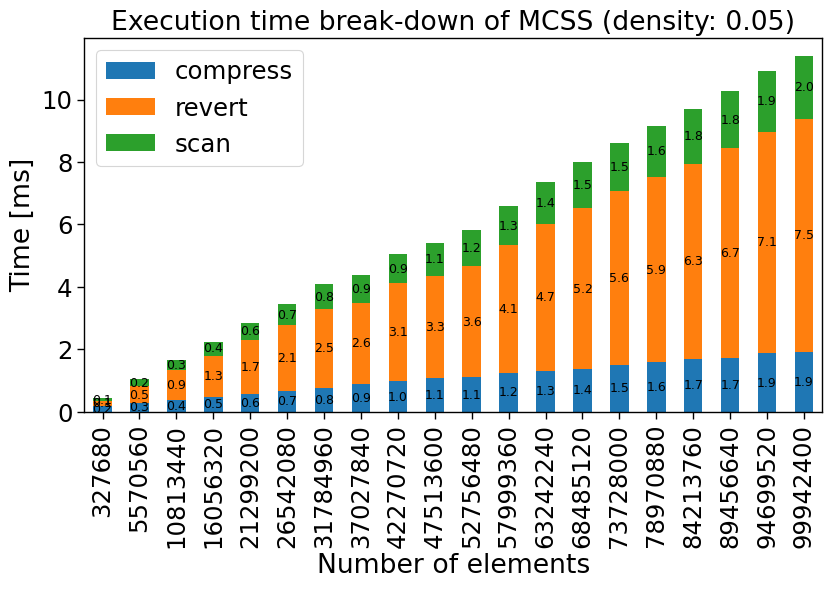

In [20]:
plt.figure(figsize=(11, 8))

pivot_df = tot_dataframe.pivot(index='size', columns='operator', values='time_ms')
ax = pivot_df.plot(kind='bar', stacked=True)

plt.xlabel('Number of elements')
plt.ylabel('Time [ms]')
plt.title('Execution time break-down of MCSS (density: 0.05)')
plt.legend(loc="upper left")
plt.tight_layout()

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', label_type='center', color='black', fontsize=9)

#plt.grid(True)
plt.savefig("mcss_time_breakdown.pdf")
plt.savefig("mcss_time_breakdown.png")
plt.show()
